# Project 3 - Stiching Photo Mosaics

In [1]:
# load libraries
import numpy as np
import skimage as sk
import skimage.io as skio
from skimage import img_as_ubyte
import matplotlib.pyplot as plt

## A.2 Recover Homographies

In [17]:
def computeH(im1_pts, im2_pts):
    n = im1_pts.shape[0] # number of rows in im1
    A = [] # 2 x n rows

    for i in range(n):
        x, y = im1_pts[i, 0], im1_pts[i, 1] # coordinate
        x_prime, y_prime = im2_pts[i, 0], im2_pts[i, 1] # new coordinate

        # system of equations from homogeneous coordinates
        A.append([-x, -y, -1, 0, 0, 0, x * x_prime, y * x_prime, x_prime])
        A.append([0, 0, 0, -x, -y, -1, x * y_prime, y * y_prime, y_prime])

    A = np.array(A)
    U, S, Vt = np.linalg.svd(A)
    h = Vt[-1, :] # last row of V^T is eigenvector with smallest singular value
    H = h.reshape((3, 3)) # turn into 3 x 3
    H = H/ H[2, 2] # normalize

    return H

In [5]:
%matplotlib qt

In [ ]:
# load images
im1 = skio.imread("pics/grimes1.png")
im2 = skio.imread("pics/grimes2.png")

# choose pts im1
plt.imshow(im1)
plt.title("Click 4+ points in Image 1, close the window when done")
pts1 = np.array(plt.ginput(n=-1, timeout=0)) # click as many points as needed ?
plt.close()

In [ ]:
# choose pts im2
plt.imshow(im2)
plt.title("Click corresponding points in Image 2, same order")
pts2 = np.array(plt.ginput(n=len(pts1), timeout=0))
plt.close()

print("Points from image 1:\n", pts1)
print("Points from image 2:\n", pts2)

Points from image 1:
 [[ 174.59090909 1393.68181818]
 [ 174.59090909 1737.31818182]
 [1491.86363636  714.59090909]
 [2670.04545455 1377.31818182]]
Points from image 2:
 [[1352.77272727 1508.22727273]
 [1352.77272727 1786.40909091]
 [2383.68181818  755.5       ]
 [3913.68181818 1279.13636364]]


In [10]:
%matplotlib inline

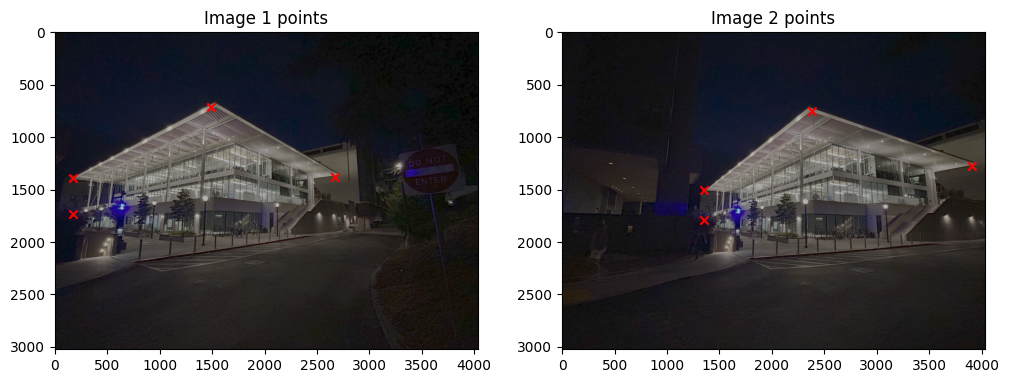

In [ ]:
# visual side by side comparison of chosen img pts
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(im1)
axes[0].scatter(pts1[:, 0], pts1[:, 1], c='r', marker='x')
axes[0].set_title("Image 1 points")

axes[1].imshow(im2)
axes[1].scatter(pts2[:, 0], pts2[:, 1], c='r', marker='x')
axes[1].set_title("Image 2 points")

plt.show()

In [12]:
H = computeH(pts1, pts2)
print("Recovered Homography:\n", H)

Recovered Homography:
 [[ 4.98766897e-01 -2.55270010e-01  1.24954894e+03]
 [-2.52170353e-02  5.41147956e-01  1.68630457e+02]
 [-6.83525154e-05 -1.88701328e-04  1.00000000e+00]]


## A.3 Warp the Images

In [14]:
# handling if warped images might extend outide original frame
def compute_output_bounds(im, H):
    h, w = im.shape[:2]
    corners = np.array([[0, 0, 1],
                        [w-1, 0, 1],
                        [0, h-1, 1],
                        [w-1, h-1, 1]])
    warped = (H @ corners.T).T # transform corners of input with H
    warped = warped[:, :2] / warped[:, 2:] # normalize
    min_x, min_y = warped.min(axis=0)
    max_x, max_y = warped.max(axis=0)
    return int(np.floor(min_x)), int(np.floor(min_y)), int(np.ceil(max_x)), int(np.ceil(max_y))

In [15]:
def warpImageNearestNeighbor(im, H):
    Hinv = np.linalg.inv(H)
    h, w = im.shape[:2]
    
    # find output bounds
    min_x, min_y, max_x, max_y = compute_output_bounds(im, H)
    out_w, out_h = max_x - min_x, max_y - min_y
    
    out = np.zeros((out_h, out_w, im.shape[2]), dtype=im.dtype)
    
    for yy in range(out_h):
        for xx in range(out_w):
            # coords in output image
            x_out, y_out = xx + min_x, yy + min_y
            
            # map back into input coords
            src = Hinv @ np.array([x_out, y_out, 1])
            x_src, y_src = src[0]/src[2], src[1]/src[2]
            
            # nearest neighbor
            xi, yi = int(round(x_src)), int(round(y_src))
            
            if 0 <= xi < w and 0 <= yi < h:
                out[yy, xx] = im[yi, xi]
    
    return out

In [16]:
def warpImageBilinear(im, H):
    Hinv = np.linalg.inv(H)
    h, w = im.shape[:2]
    
    min_x, min_y, max_x, max_y = compute_output_bounds(im, H)
    out_w, out_h = max_x - min_x, max_y - min_y
    
    out = np.zeros((out_h, out_w, im.shape[2]), dtype=im.dtype)
    
    for yy in range(out_h):
        for xx in range(out_w):
            x_out, y_out = xx + min_x, yy + min_y
            src = Hinv @ np.array([x_out, y_out, 1])
            x_src, y_src = src[0]/src[2], src[1]/src[2]
            
            if 0 <= x_src < w-1 and 0 <= y_src < h-1:
                # floor and ceil
                x0, y0 = int(np.floor(x_src)), int(np.floor(y_src))
                dx, dy = x_src - x0, y_src - y0
                
                # grab 4 neighbors
                top_left = im[y0, x0]
                top_right = im[y0, x0+1]
                bottom_left = im[y0+1, x0]
                bottom_right = im[y0+1, x0+1]
                
                # bilinear interpolate
                top = (1-dx)*top_left + dx*top_right
                bottom = (1-dx)*bottom_left + dx*bottom_right
                value = (1-dy)*top + dy*bottom
                
                out[yy, xx] = value
    
    return out.astype(im.dtype)

In [ ]:
%matplotlib qt

# load rectangle image
im = skio.imread("pics/poke.png")

plt.imshow(im)
plt.title("Click 4 corners of the rectangle (clockwise)")
pts = plt.ginput(4, timeout=0)
plt.close()

im1_pts = np.array(pts) # (4x2)
print("Points from image:", im1_pts)

# need to define correspondences based on what we know about image
# define by hand
width, height = 500, 400 # how much does this impact warping?
im2_pts = np.array([
    [0, 0],
    [width-1, 0],
    [width-1, height-1],
    [0, height-1]
])

# compute homography
H = computeH(im1_pts, im2_pts)
print("Recovered Homography:\n", H)

# warp image (nearest neighbor)
im_warp_nn = warpImageNearestNeighbor(im, H)

# warp image (bilinear)
im_warp_bil = warpImageBilinear(im, H)

# visualize
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
axs[0].imshow(im)
axs[0].set_title("Original Image")
axs[1].imshow(im_warp_nn)
axs[1].set_title("Warped - Nearest Neighbor")
axs[2].imshow(im_warp_bil)
axs[2].set_title("Warped - Bilinear")
plt.show()

Points from image: [[318.98051948 151.88095238]
 [593.87229437 322.87662338]
 [323.30952381 742.79004329]
 [ 26.77272727 504.69480519]]
Recovered Homography:
 [[ 1.40588629e+00  1.16438435e+00 -6.25298144e+02]
 [-5.86949028e-01  9.43576286e-01  4.39140410e+01]
 [ 7.74211940e-06  5.23084236e-04  1.00000000e+00]]
